In [16]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from dataclasses import field
from copy import copy
import math
import random

In [17]:
@dataclass
class prey:
    location: int
    eaten: bool = False
    escaped: bool = False
    cooperative: bool = False

    def __str__(self):
        return (
            f"prey(\n"
            f"  location={self.location},\n"
            f"  eaten={self.eaten},\n"
            f"  escaped={self.escaped},\n"
            f"  cooperative={self.cooperative}\n"
            f")"
        )


@dataclass
class predator:
    location: int
    hunting: bool = False

    def __str__(self):
        return (
            f"predator(\n"
            f"  location={self.location},\n"
            f"  hunting={self.hunting}\n"
            f")"
        )

In [18]:
#environment will be created, initializing two prey fish and one predator.

def locations_to_list(locations, fish_type):
    """
    A function that takes a list of locations, and returns a list of fish
    at the specified locations.
    
    Parameters: 
    ------
    locations: list of ints representing the locations of the fish
    fish_type: string, either 'prey' or 'predator', indicating the type of fish
    
    Returns:
    ------
    fish_list: list of fish objects with the given locations.
    """
    
    fish_list = []
    for loc in locations:
        if fish_type == 'prey':
            my_fish = prey(location = loc)
        elif fish_type == 'predator':
            my_fish = predator(location = loc)

        fish_list.append(my_fish)
    
    return fish_list

def get_locations(prey1, prey2, pred):
    """
    Returns a NumPy array containing the locations of:
    [prey1, prey2, predator]

    If a prey has escaped, its location is set to -1.
    """

    #this is a grid of size 3x2, where the first column contains the locations of the 
    #prey and predator, and the second column contains the status of the prey 
    #(0 for alive, 2 for escaped/eaten).
    
    grid = np.zeros((3,2), dtype=int)

    if (not prey1.escaped) and (not prey1.eaten) :
        grid[0][0] = prey1.location
    elif prey1.eaten:
        grid[0][1] = 2
    if (not prey2.escaped) and (not prey2.eaten):
        grid[1][0] = prey2.location
    elif prey2.eaten:
        grid[1][1] = 2

    grid[2][0] = pred.location

    return grid

def fish_move(prey1, prey2, predator1, p):
    success = False

    prey1gone = prey1.escaped 
    prey2gone = prey2.escaped
    if not (prey1gone or prey2gone):
        success = decision_step(prey1, prey2, predator1, p)
    elif prey1gone:
        success = one_fish_step(prey2, predator1)
    elif prey2gone:
        success = one_fish_step(prey1, predator1)
    else:
        print("error1")
    return success

def one_fish_step(gprey, predator1):
    predator1.location -= 1
    if predator1.location > 50:
        predator1.location = 49
    elif predator1.location < 0:
        predator1.location = 0
    gprey.location -= 1
    if gprey.location < 0:
        gprey.escaped = True
        return True
    else:
        return False

def decision_step(prey1, prey2, predator1, p):
    """
    A function that simulates a single time-step where each prey fish makes
    a decision to cooperate or abandon their fellow fish.

    Parameters:
    ------
    prey1: a prey fish object
    prey2: a prey fish object
    predator: a predator object
    
    """

    #predator makes a random choice to move left, right, or stay in place.
    predator1.location -= 1
    #random.choice(pred_decision)
    # check if the predator has moved out of bounds
    if predator1.location > 50:
        predator1.location = 49
    elif predator1.location < 0:
        predator1.location = 0
    
    #Prey move
    decisions = ['cooperate', 'flee']
    pred_decision = [-1, 0, 1]
    #check the decisions made by either fish.
    #if both fish cooperate, they move one step away
    #if they both flee, they remain in place
    #if one cooperates and the other flees, the one that flees moves two steps away.
    decision_made = []
    for i in range(2):
        decision = np.random.choice(decisions, p=p)
        decision_made.append(decision)
    
    if decision_made[0] == decision_made[1] == 'cooperate':
        #both fish move one step away
        prey1.location -= 1
        prey2.location -= 1
        #print("cooperate")
    elif decision_made[0] == 'cooperate' and decision_made[1] == 'flee':
        #the fleeing fish moves two steps away
        prey1.location -=2
        #print("non-cooperation")
    elif decision_made[0] == 'flee' and decision_made[1] == 'cooperate':
        #the fleeing fish moves two steps away
        prey2.location -= 2
        #print("non-cooperation")
    
    # check if the prey have escaped
    if prey1.location < 0:
        prey1.escaped = True
    if prey2.location < 0:
        prey2.escaped = True
        
    success = prey1.escaped and  prey2.escaped   
    return success


def eat(prey1, prey2, predator1):
    """
    A function that simulates a hunting step, where the predator can hunt its
    prey depending on its distance to the prey fish.

    Parameters:
    ------
    prey_list: list of prey fish objects
    predator: a predator object

    Returns:
    ------
    prey_list: list of prey fish objects with updated eaten status
    predator: updated predator object
    """
    twofish = True
    probability1 = 0
    probability2 = 0
    
    distance1 = np.abs(prey1.location - predator1.location)
    if distance1 < 10:
        probability1 = 1 - distance1/10
        
    distance2 = np.abs(prey2.location - predator1.location)
    if distance2 < 10:
        probability2 = 1 - distance2/10
    
    r = np.random.random()
    if r < probability1:
        prey1.eaten = True
        twofish = False
    if r < probability2:
        prey2.eaten = True
        twofish = False
                
    return not twofish


#changing.

In [57]:
def run1dSimulation(p):
    """
    The "main" function that run the 1d simulation
    
    input:
    T timestep in integer

    Return:
    LISTS: a array of lists at each timestep
    """
    grids = []
    prey1 = prey(25)
    prey2 = prey(25)
    predator1 = predator(49)
    grid = get_locations(prey1, prey2, predator1)
    grids.append(grid)
    T = 0
    fail = False
    #add the fish of fish_type at locations to fishlist
    while not fail:
        success = fish_move(prey1, prey2, predator1, p) #the new fish list after this time step
        T+=1
        if success:
            #print("success")
            grid = get_locations(prey1, prey2, predator1)
            grids.append(grid)
            #print(prey1, prey2, predator1)
            return grids,T, True
        fail = eat(prey1, prey2, predator1) #the updated fish list if 
        grid = get_locations(prey1, prey2, predator1)
        grids.append(grid)
    #print("fail")
    return grids, T, False

In [55]:
def visualize(grids):
    for grid in grids:
        line = ""
        print(grid)
        for i in range(50):
            if i == grid[0][0]:
                line += "X" if grid[1][1] == 2 else "■"
            if i == grid[1][0]:
                line += "X" if grid[0][1] == 2 else "■"
            elif i == grid[2][0]:
                line += "●"
            else:
                line += "☐"

        print(line)


In [35]:
grids, T = run1dSimulation(p=[0.5, 0.5])
print(T)
visualize(grids)

success
prey(
  location=-1,
  eaten=False,
  escaped=True,
  cooperative=False
) prey(
  location=-2,
  eaten=False,
  escaped=True,
  cooperative=False
) predator(
  location=12,
  hunting=False
)
37
[[25  0]
 [25  0]
 [49  0]]
☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐■■☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐●
[[25  0]
 [23  0]
 [48  0]]
☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐■☐■☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐●☐
[[24  0]
 [22  0]
 [47  0]]
☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐■☐■☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐●☐☐
[[22  0]
 [22  0]
 [46  0]]
☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐■■☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐●☐☐☐
[[22  0]
 [22  0]
 [45  0]]
☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐■■☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐●☐☐☐☐
[[20  0]
 [22  0]
 [44  0]]
☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐■☐☐■☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐●☐☐☐☐☐
[[18  0]
 [22  0]
 [43  0]]
☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐■☐☐☐☐■☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐●☐☐☐☐☐☐
[[16  0]
 [22  0]
 [42  0]]
☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐■☐☐☐☐☐☐■☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐●☐☐☐☐☐☐☐
[[14  0]
 [22  0]
 [41  0]]
☐☐☐☐☐☐☐☐☐☐☐☐☐☐■☐☐☐☐☐☐☐☐■☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐●☐☐☐☐☐☐☐☐
[[13  0]
 [21  0]
 [40  0]]
☐☐☐☐☐☐☐☐☐☐☐☐☐■☐☐☐☐☐☐☐☐■☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐☐●☐☐☐☐☐☐☐☐

In [60]:
Ts1 = [] #sacostic
for i in range(1000):
    grids, T, success = run1dSimulation(p=[0.5, 0.5])
    if success:
        Ts1.append(T)


Ts2 = [] #non cooperative
for i in range(1000):
    grids, T, success = run1dSimulation(p=[0.33, 0.67])
    if success:
        Ts2.append(T)

Ts3 = [] #cooperative
for i in range(1000):
    grids, T, success = run1dSimulation(p=[0.67, 0.33])
    if success:
        Ts3.append(T)

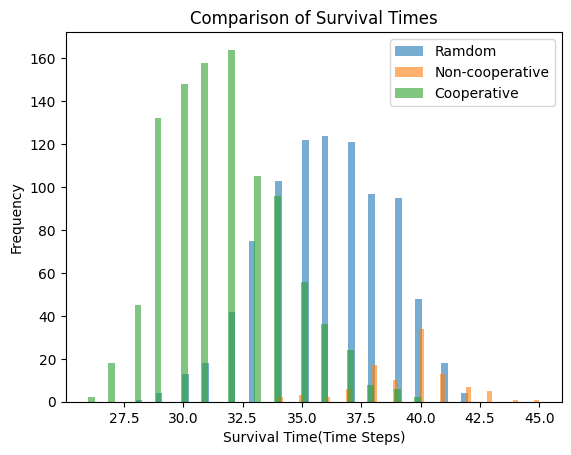

In [64]:
plt.hist(Ts1, bins=50, alpha=0.6, label='Ramdom')
plt.hist(Ts2, bins=50, alpha=0.6, label='Non-cooperative')
plt.hist(Ts3, bins=50, alpha=0.6, label='Cooperative')

plt.xlabel("Survival Time(Time Steps)")
plt.ylabel("Frequency")
plt.title("Comparison of Survival Times")
plt.legend()

plt.show()